In [21]:
import healpy as hp
import numpy as np
import tensorflow as tf, sys, os
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter
tf.keras.backend.clear_session() #clear any previous models

plots_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/"
data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data/"
os.chdir(data_directory)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress TF warnings
print("Current working directory:", os.getcwd())

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data


In [2]:
print("TF:", tf.__version__)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

TF: 2.10.1
Python: 3.10.15
LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64


Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
NSIDE: 256


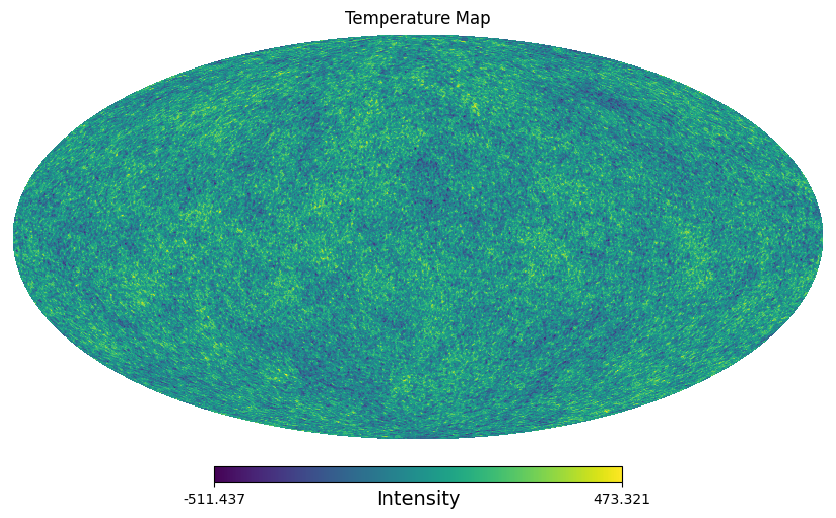

In [3]:
from SkyNeuralNets import read_map
#Read the data
path_lcdm = "./simulated_maps/"
map_temp_data = read_map(path_lcdm + 'cmb_map_0.fits')

#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
#nside = 64
print(f"NSIDE: {nside}")

#Plot
hp.mollview(map_temp_data, title="Temperature Map", unit="Intensity")
plt.show()

In [4]:
def read_all_maps(path_lcdm, path_feature, n_maps=100):
    maps = []
    labels = []
    
    #LCDM maps
    for i in range(n_maps):
        map_lcdm = read_map(f"{path_lcdm}cmb_map_{i}.fits")
        maps.append(map_lcdm)
        labels.append(0)  #lcdm
    
    #Feature maps
    for i in range(n_maps):
        map_feature = read_map(f"{path_feature}cmb_map_feature_{i}.fits")
        maps.append(map_feature)
        labels.append(1)  #feature
    
    maps = np.array(maps).astype(np.float32)[..., None]  #Add channel dimension
    labels = np.array(labels).astype(np.int32)
    #print(labels)
    return maps, labels

In [5]:
def map_to_image(hp_map, xsize=256):
    #Validate that map has correct length
    hp_map = np.asarray(hp_map, dtype=np.float64)
    try:
        nside = hp.get_nside(hp_map)
    except Exception as e:
        print("Invalid map shape:", hp_map.shape)
        raise e
    img = hp.cartview(hp_map, xsize=xsize, return_projected_map=True, title="", cbar=False)
    plt.close()
    return img

In [6]:
path_feature = "./simulated_maps/"
x_raw, y_raw = read_all_maps(path_lcdm, path_feature, n_maps=225) #0: lcdm, 1:feature

Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C  

In [7]:
x_raw_new = np.array(x_raw).squeeze()

In [8]:
imgs = np.array([map_to_image(m) for m in x_raw_new])
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]  #add channel dimension

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)
X_test, X_val, y_test, y_val = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)

In [19]:
np.shape(X_train)

(360, 128, 256, 1)

In [20]:
#Check the class weights to handle imbalance
from sklearn.utils import class_weight
print(f"Training set Class 1 ratio: {y_train.mean():.4f}")
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

Training set Class 1 ratio: 0.4889


In [ ]:
def z_score_norm_per_map(X_set):
    """Applies z-score normalization to each map individually."""
    # Squeeze to 3D (maps, h, w) if it's 4D (maps, h, w, 1)
    needs_reshape = False
    if X_set.ndim == 4 and X_set.shape[-1] == 1:
        X_set = X_set.squeeze(axis=-1)
        needs_reshape = True
    
    # Calculate mean and std for each map (axis=(1, 2))
    mu = np.mean(X_set, axis=(1, 2), keepdims=True, dtype=np.float64)
    std = np.std(X_set, axis=(1, 2), keepdims=True, dtype=np.float64)
    
    # Avoid divide-by-zero for blank maps
    std[std == 0] = 1.0 
    
    scaled_X = ((X_set - mu) / std).astype(np.float32)
    
    if needs_reshape:
        scaled_X = np.expand_dims(scaled_X, axis=-1)
        
    return scaled_X

In [ ]:
X_train = z_score_norm_per_map(X_train)
X_val = z_score_norm_per_map(X_val)
X_test = z_score_norm_per_map(X_test)

In [14]:
def se_block(input_tensor, reduction_ratio=16):
    """
    Squeeze-and-Excitation block.
    This "attention" block learns to re-weight feature channels,
    "amplifying" the ones that contain the signal and suppressing noise.
    """
    channels = input_tensor.shape[-1]
    
    # Squeeze: Global average pooling
    x = layers.GlobalAveragePooling2D()(input_tensor)
    
    # Excitation: Two dense layers
    x = layers.Dense(channels // reduction_ratio, activation="relu", use_bias=False)(x)
    x = layers.Dense(channels, activation="sigmoid", use_bias=False)(x)
    
    # Reshape and scale input tensor
    x = layers.Reshape((1, 1, channels))(x)
    return layers.multiply([input_tensor, x])

In [15]:
def create_attention_cnn(input_shape):
    """
    Creates a deeper CNN architecture that replaces MaxPooling with
    strided convolutions (less destructive) and uses Squeeze-and-Excitation
    (attention) to amplify faint signals.
    """
    img_input = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(img_input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x) # Add attention

    # Downsample 1 (Replaces MaxPooling)
    x = layers.Conv2D(64, (3,3), strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x) # Add attention

    # Block 2
    x = layers.Conv2D(128, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x) # Add attention

    # Downsample 2 (Replaces MaxPooling)
    x = layers.Conv2D(128, (3,3), strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x) # Add attention
    
    # Block 3
    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x) # Add attention
    
    # Final Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation="sigmoid")(x)
    
    model = models.Model(inputs=img_input, outputs=output)
    return model

# --- Create the new, more powerful model ---
model = create_attention_cnn(input_shape=X_train.shape[1:])

2025-10-31 13:48:03.170606: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2025-10-31 13:48:03.349109: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2025-10-31 13:48:03.578838: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (login210-19): /proc/driver/nvidia/version does not exist
2025-10-31 13:48:05.616495: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model.summary(110)

cb = [
  tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=150, mode="max", restore_best_weights=True),
  tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=4, mode="max", min_lr=1e-6)
]

Model: "model"
______________________________________________________________________________________________________________
 Layer (type)                       Output Shape            Param #      Connected to                         
 input_1 (InputLayer)               [(None, 128, 256, 1)]   0            []                                   
                                                                                                              
 conv2d (Conv2D)                    (None, 128, 256, 32)    288          ['input_1[0][0]']                    
                                                                                                              
 batch_normalization (BatchNormaliz  (None, 128, 256, 32)   128          ['conv2d[0][0]']                     
 ation)                                                                                                       
                                                                                                 

In [23]:
history = model.fit(
    X_train,
    y_train, 
    epochs=500, 
    batch_size=32, 
    validation_data=(X_val, y_val),
    callbacks=cb,
)

Epoch 1/500
12/12 [==============================] - 43s 3s/step - loss: 0.7051 - accuracy: 0.4917 - auc: 0.5099 - val_loss: 0.7571 - val_accuracy: 0.5444 - val_auc: 0.4781 - lr: 1.0000e-04
Epoch 2/500
12/12 [==============================] - 33s 3s/step - loss: 0.7061 - accuracy: 0.5111 - auc: 0.4924 - val_loss: 0.7072 - val_accuracy: 0.5444 - val_auc: 0.4664 - lr: 1.0000e-04
Epoch 3/500
12/12 [==============================] - 34s 3s/step - loss: 0.7028 - accuracy: 0.5250 - auc: 0.5301 - val_loss: 0.7000 - val_accuracy: 0.5444 - val_auc: 0.4684 - lr: 1.0000e-04
Epoch 4/500
12/12 [==============================] - 35s 3s/step - loss: 0.6997 - accuracy: 0.5528 - auc: 0.5494 - val_loss: 0.7016 - val_accuracy: 0.5444 - val_auc: 0.5047 - lr: 1.0000e-04
Epoch 5/500
12/12 [==============================] - 37s 3s/step - loss: 0.7053 - accuracy: 0.5250 - auc: 0.4989 - val_loss: 0.6996 - val_accuracy: 0.5444 - val_auc: 0.4604 - lr: 1.0000e-04
Epoch 6/500
12/12 [==============================]

: 

In [ ]:
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

12/12 [==============================] - 3s 189ms/step - loss: 146.1568 - accuracy: 0.5111 - auc: 0.5000
Test accuracy: 0.5111


Text(0, 0.5, 'Accuracy')

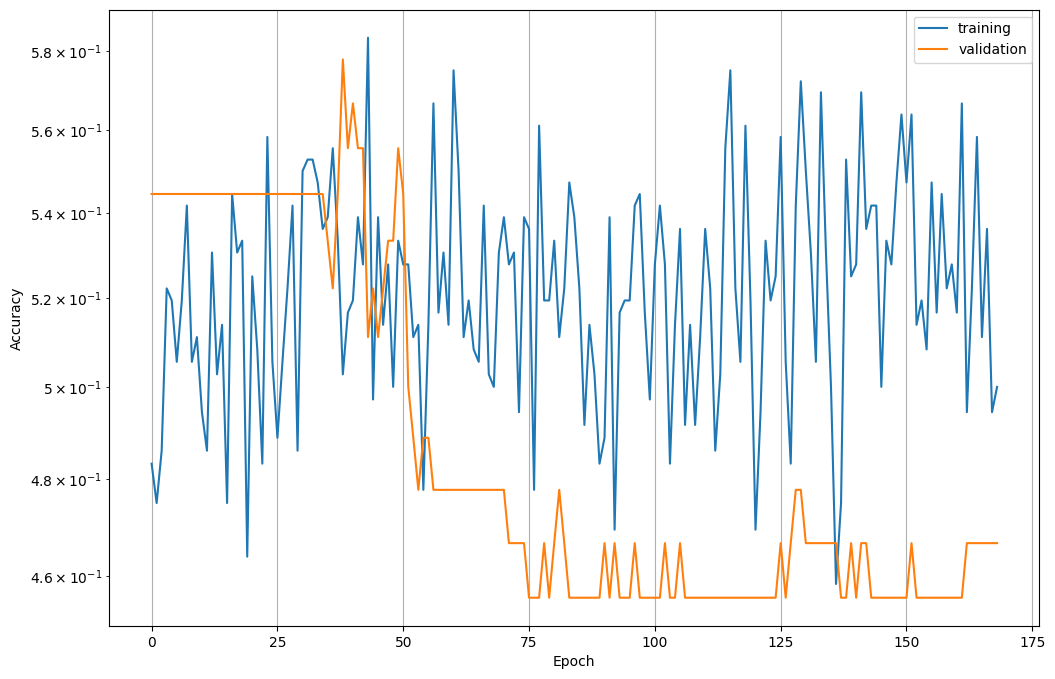

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(history.history["accuracy"], label="training")
plt.plot(history.history["val_accuracy"], label="validation")
plt.grid()
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Loss')

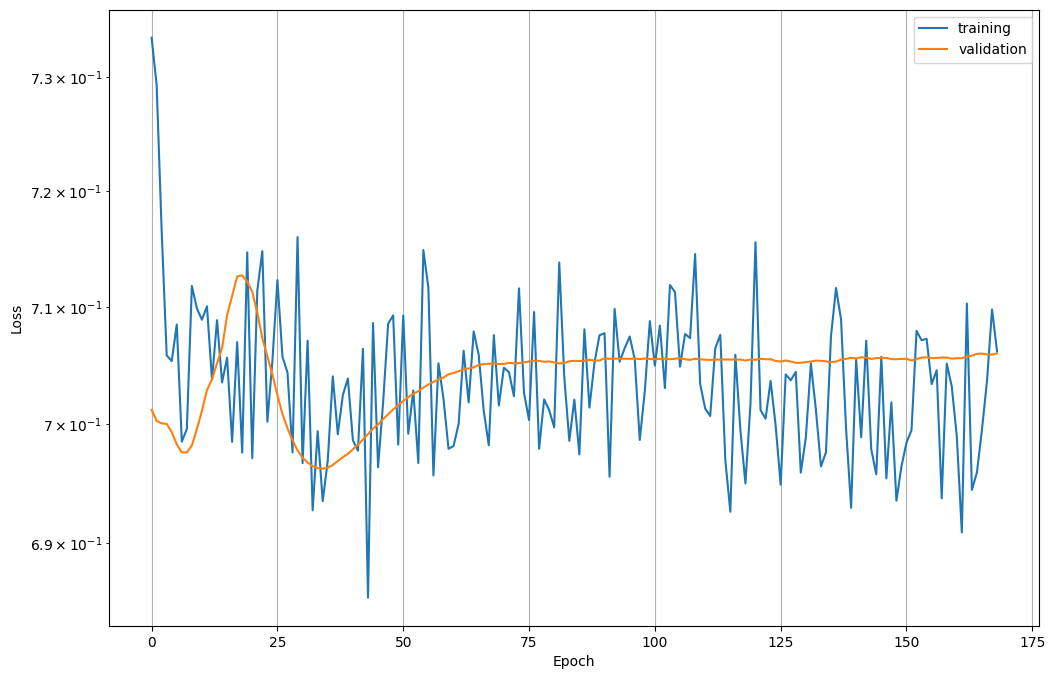

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(history.history["loss"], label="training")
plt.plot(history.history["val_loss"], label="validation")
plt.grid()
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [ ]:
#sanity check
print(np.mean(X_train), np.std(X_train))   #mean~0, st.dev~1
print(np.mean(X_test),  np.std(X_test))    #should be close to train

-1.8436226025963975 101.69792547834403
-1.8436226025963975 101.69792547834403


In [ ]:
# Get model probabilities
probs = model.predict(X_test, batch_size=64).ravel()

6/6 [==============================] - 2s 220ms/step


In [ ]:
#Check the class balance, do we have a 50/50 split?
print("class balance test:", (y_test==1).mean())

class balance test: 0.4888888888888889


In [ ]:
#Let's check the ranges of probabilities, why is the CNN classfiying everything as LCDM?
print("min/max/mean probs:", probs.min(), probs.max(), probs.mean())

min/max/mean probs: 1.0 1.0 1.0


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

#Find optimal threshold from ROC
fpr, tpr, thr = roc_curve(y_test, probs)
t_opt = thr[np.argmax(tpr - fpr)]
print("AUC:", auc(fpr, tpr), "t*:", t_opt)

#Apply the new threshold to get predictions, Youden's index https://en.wikipedia.org/wiki/Youden%27s_J_statistic
pred = (probs >= t_opt).astype(int)

#Accuracy
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

#Confusion matrix
cm = confusion_matrix(y_test, pred, labels=[0, 1])
print("Confusion matrix:\n", cm)


AUC: 0.5 t*: inf
Accuracy: 0.5111111111111111
Confusion matrix:
 [[184   0]
 [176   0]]


In [ ]:
#-----------------------------------------------------------------------------------------------------------
#Performance: correct & incorrect  predictions
#-----------------------------------------------------------------------------------------------------------
#True positive: LCDM=0, Feature=1
true_LCDM = []
true_MoG = []
false_LCDM = []
false_MoG = []

for pred, true in zip(pred, y_test):
    if pred==0 and true==0:
        true_LCDM.append(1)
    if pred==1 and true==1:
        true_MoG.append(1)
    if pred==0 and true==1:
        false_LCDM.append(1)
    if pred==1 and true==0:
        false_MoG.append(1)
lenghts=[len(true_LCDM),len(true_MoG),len(false_LCDM),len(false_MoG)]

print('     ','LCDM','FT')
print('True ',len(true_LCDM)/sum(lenghts),len(true_MoG)/sum(lenghts))
print('False',len(false_LCDM)/sum(lenghts),len(false_MoG)/sum(lenghts))
print('--------------')
print("Correct prediction: ",(len(true_LCDM)+len(true_MoG))/sum(lenghts))
print("Wrong prediction  : ",(len(false_LCDM)+len(false_MoG))/sum(lenghts))

      LCDM FT
True  0.5111111111111111 0.0
False 0.4888888888888889 0.0
--------------
Correct prediction:  0.5111111111111111
Wrong prediction  :  0.4888888888888889


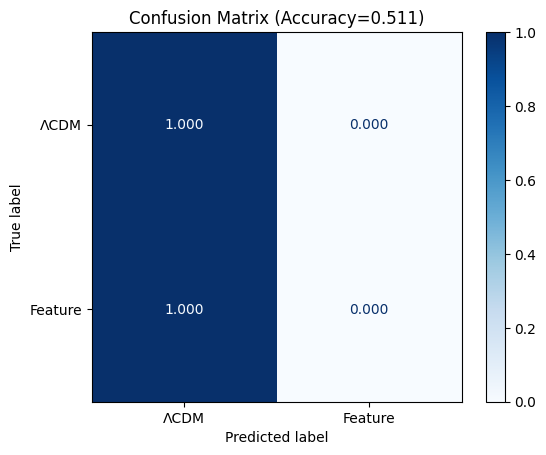

In [ ]:
#Plot confusion matrix
cm_prob = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_prob, display_labels=["ΛCDM", "Feature"])
disp.plot(cmap="Blues", values_format='.3f')
plt.title(f"Confusion Matrix (Accuracy={acc:.3f})")
#plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/confusion_matrix.png", dpi=300)
plt.show()

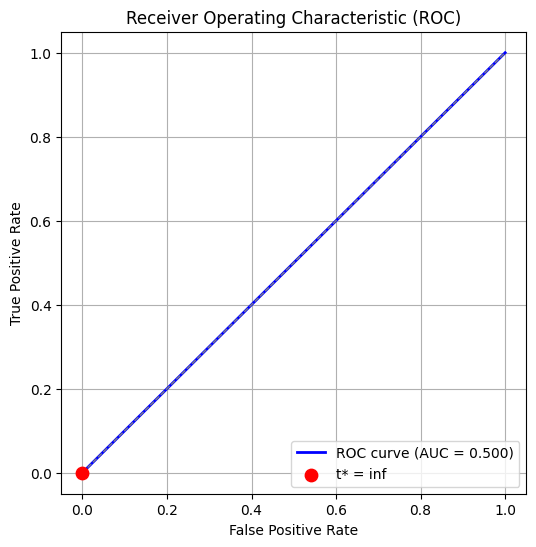

In [ ]:
#Plot the ROC curve with Youden index (https://en.wikipedia.org/wiki/Youden%27s_J_statistic#/media/File:ROC_Curve_T1D_Validation,_top5_r2filtered.svg)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

t_star_idx = np.argmax(tpr - fpr)
t_star = thr[t_star_idx]

#Mark t* point
plt.scatter(fpr[t_star_idx], tpr[t_star_idx], color="red", s=80, zorder=5,
            label=f"t* = {t_star:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()